**Campus Placement**


* Please upvote and let me know if any mistake. 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/factors-affecting-campus-placement/Placement_Data_Full_Class.csv


# <a id='intro'>1. Project Overview</a>

* Predict how many students are placed in campus recruitment.

* These placement based on SSC, HSC and degree percentages.

# <a id='intro'>2. About Dataset i.e. what indicate the features</a>

1. **specializationsl_no :-** serial number
2. **Gender:-** gender identification M or F
3. **ssc_p:-** SSC percentage
4. **ssc_b:-** information about SSC board i.e. central board or state board. State board is with respect to a particular state.
5. **hsc_p:-** HSC percentage
6. **hsc_b:-** information about HSC board i.e. central board or state board. State board is with respect to a particular state.
7. **hsc_s:-** which branch completed the HSC? Commerce, science, and art
8. **degree_p:-** Degree percentage
9. **degree_t:-** which branch completed the degree? sci&tech and comm&mgmt
10. **workex:-** any work experience ‘YES’ or ‘NO’
11. **etest_p:-** test percentage
12. **specialisation:-** branch specialization i.e. Mkt&HR, Mky&Fin
13. **mba_p:-** MBA percentage
14. **Status:-** About placement, he/she placed or not placed.


**I will be solve this problem with two steps**
1. By using python with step-by-step
2. By using AutoML technique

> <span style='color:Red'> **Import Required Libraries** </span>

In [2]:
#import pandas 
import pandas as pd

#import numpy
import numpy as np

#import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# ignore the warnings
import warnings
warnings.filterwarnings('ignore')

> > <span style='color:Red'> **Read the Dataset** </span>

In [3]:
df = pd.read_csv('../input/factors-affecting-campus-placement/Placement_Data_Full_Class.csv')

> <span style='color:Blue'> **Check data values, data types, data informatios.** </span>

In [4]:
#Print top five rows
print("Top Five Rows is:-")
df.head()

Top Five Rows is:-


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [5]:
#Print last five rows
print("Last Five Rows is:-")
df.tail()

Last Five Rows is:-


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
210,211,M,80.6,Others,82.0,Others,Commerce,77.6,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.0,Others,60.0,Others,Science,72.0,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.0,Others,67.0,Others,Commerce,73.0,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.0,Others,66.0,Others,Commerce,58.0,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0
214,215,M,62.0,Central,58.0,Others,Science,53.0,Comm&Mgmt,No,89.0,Mkt&HR,60.22,Not Placed,NaN


**How many features are int, float and objects?**

In [6]:
#check information about given dataset
print("The information is:-")
df.info()

The information is:-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


* There are total 15 columns.
* There are 1 int column, 6 float column and 8 object column.
* Total number of example is 215 and it start from 0. Because of python indexing always statrt from 0.
* float64 uses 64 bits. That means that float64's take up twice as much memory

**What is central tendency value of numeric column?**

In [7]:
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


* describe will help to calculate the mean, median and mode. Also calculate the variance, standard deviation, maximum and minimum value.

* but this would be work for only numeric column, what about non-numeric columns?

In [8]:
#for non-numeric

df.describe(include='all')

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
count,215.000000,215,215.000000,215,215.000000,215,215,215.000000,215,215,215.000000,215,215.000000,215,148.000000
unique,NaN,2,NaN,2,NaN,2,3,NaN,3,2,NaN,2,NaN,2,NaN
top,NaN,M,NaN,Central,NaN,Others,Commerce,NaN,Comm&Mgmt,No,NaN,Mkt&Fin,NaN,Placed,NaN
freq,NaN,139,NaN,116,NaN,131,113,NaN,145,141,NaN,120,NaN,148,NaN
mean,108.000000,NaN,67.303395,NaN,66.333163,NaN,NaN,66.370186,NaN,NaN,72.100558,NaN,62.278186,NaN,288655.405405
std,62.209324,NaN,10.827205,NaN,10.897509,NaN,NaN,7.358743,NaN,NaN,13.275956,NaN,5.833385,NaN,93457.452420
min,1.000000,NaN,40.890000,NaN,37.000000,NaN,NaN,50.000000,NaN,NaN,50.000000,NaN,51.210000,NaN,200000.000000
25%,54.500000,NaN,60.600000,NaN,60.900000,NaN,NaN,61.000000,NaN,NaN,60.000000,NaN,57.945000,NaN,240000.000000
50%,108.000000,NaN,67.000000,NaN,65.000000,NaN,NaN,66.000000,NaN,NaN,71.000000,NaN,62.000000,NaN,265000.000000
75%,161.500000,NaN,75.700000,NaN,73.000000,NaN,NaN,72.000000,NaN,NaN,83.500000,NaN,66.255000,NaN,300000.000000


* for non-numeric used above method.

* They show count the class label, count an unique values and many more.

In [9]:
#if want only object columns

df.describe(include='object') #use only for object features.

,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
count,215,215,215,215,215,215,215,215
unique,2,2,2,3,3,2,2,2
top,M,Central,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
freq,139,116,131,113,145,141,120,148


In [10]:
#if want only float64

df.describe(include='float64')  #only for float values

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [11]:
#if want only integer

df.describe(include='int64') #only for integers

,sl_no
count,215.000000
mean,108.000000
std,62.209324
min,1.000000
25%,54.500000
50%,108.000000
75%,161.500000
max,215.000000


In [12]:
#excluding object columns form given dataframe
#if want only numeric without object use this 

df.describe(exclude='object') #except object column

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


# <a id='intro'>3. Checking Null Values</a>

In [13]:
#null vlaues

df.isnull() 
#just show is there any null value in terms of boolean.

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
211,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
212,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
213,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
#how many null values

df.isnull().any().sum()

1

* Yes there is one value is missing.

In [15]:
df.isnull().any()
#missing value in salary feature

sl_no             False
gender            False
ssc_p             False
ssc_b             False
hsc_p             False
hsc_b             False
hsc_s             False
degree_p          False
degree_t          False
workex            False
etest_p           False
specialisation    False
mba_p             False
status            False
salary             True
dtype: bool

In [16]:
df.isna().sum()
#there are total 67 vlaues are missing in salary column,

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [17]:
#any missing values?
df.isnull().values.any()

True

In [18]:
#total number of missing values

df.isnull().sum().sum()

67

In [19]:
# Replace using median 
median = df['salary'].median()
df['salary'].fillna(median, inplace=True)

In [20]:
#after filling check null values
#total number of missing values

df.isnull().sum().sum()

0

> <span style='color:Blue'> **Filling the null values** </span>

In [21]:

from scipy.stats import kurtosis, skew
import matplotlib.pyplot as plt

In [22]:
skewValue = df.skew(axis=1)

In [23]:
skewValue

0      2.645751
1      2.645751
2      2.645751
3      2.645751
4      2.645751
         ...   
210    2.645751
211    2.645750
212    2.645750
213    2.645748
214    2.645749
Length: 215, dtype: float64

# <a id='intro'>4. Convert object into numeric</a>

* One hot encoding mostly use for converting the non-numeric to numeric.
* As well it works well on large dataset.
* One hot encoding creats a new column(binary column), indicating the presence of each possible value from original data.

In [24]:
encoding_cat = pd.get_dummies(df)


In [25]:
encoding_cat.head()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,gender_F,gender_M,ssc_b_Central,...,hsc_s_Science,degree_t_Comm&Mgmt,degree_t_Others,degree_t_Sci&Tech,workex_No,workex_Yes,specialisation_Mkt&Fin,specialisation_Mkt&HR,status_Not Placed,status_Placed
0,1,67.00,91.00,58.00,55.0,58.80,270000.0,0,1,0,...,0,0,0,1,1,0,0,1,0,1
1,2,79.33,78.33,77.48,86.5,66.28,200000.0,0,1,1,...,1,0,0,1,0,1,1,0,0,1
2,3,65.00,68.00,64.00,75.0,57.80,250000.0,0,1,1,...,0,1,0,0,1,0,1,0,0,1
3,4,56.00,52.00,52.00,66.0,59.43,265000.0,0,1,1,...,1,0,0,1,1,0,0,1,1,0
4,5,85.80,73.60,73.30,96.8,55.50,425000.0,0,1,1,...,0,1,0,0,1,0,1,0,0,1


> # <a id='intro'>5. Outliers</a>

In [26]:
import seaborn as sns

* Plot the skewness plot and identify any outliers values.
* Generally me work on numeric columns.

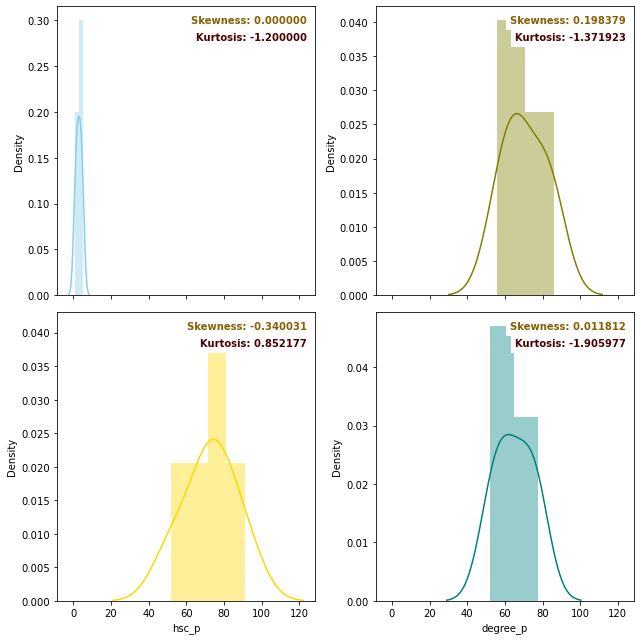

In [27]:
f, axes = plt.subplots(2, 2, figsize=(9, 9), sharex=True)

sns.distplot(encoding_cat.head().iloc[:,0], color="skyblue", ax=axes[0,0])
sns.distplot(encoding_cat.head().iloc[:,1], color="olive", ax=axes[0,1])
sns.distplot(encoding_cat.head().iloc[:,2], color="gold", ax=axes[1,0])
sns.distplot(encoding_cat.head().iloc[:,3], color="teal", ax=axes[1,1])

for i, ax in enumerate(axes.reshape(-1)):
    ax.text(x=0.97, y=0.97, transform=ax.transAxes, s="Skewness: %f" % encoding_cat.head().iloc[:,i].skew(),\
        fontweight='demibold', fontsize=10, verticalalignment='top', horizontalalignment='right',\
        backgroundcolor='white', color='xkcd:poo brown')
    ax.text(x=0.97, y=0.91, transform=ax.transAxes, s="Kurtosis: %f" % encoding_cat.head().iloc[:,i].kurt(),\
        fontweight='demibold', fontsize=10, verticalalignment='top', horizontalalignment='right',\
        backgroundcolor='white', color='xkcd:dried blood')
plt.tight_layout()

**Conclusion**

* From visualization it concluded that dataset is normal distribution. also called as gaussian distribution curve.

* This curve shows that all values are normally distributed. It means that mean, median and variance aprrox equal. 

* # <a id='intro'>6. Skewness and Kurtosis</a>

* **Kurtosis** is a measure of whether or not a distribution is heavy-tailed or light-tailed relative to a normal distribution. 

* **Skewness** is a measure of the asymmetry of a distribution. This value can be positive or negative.

In [28]:
#calculate the skewness

print("The skewness is:", df.skew())

The skewness is: sl_no       0.000000
ssc_p      -0.132649
hsc_p       0.163639
degree_p    0.244917
etest_p     0.282308
mba_p       0.313576
salary      4.440111
dtype: float64


In [29]:
#calculate the kurtosis

print("The kurtosis is:", df.kurtosis())

The kurtosis is: sl_no       -1.200000
ssc_p       -0.607510
hsc_p        0.450765
degree_p     0.052143
etest_p     -1.088580
mba_p       -0.470723
salary      28.453510
dtype: float64


* # <a id='intro'>7. Visualization</a>

*  .plot() to a DataFrame and it will generate a default visualization for the data. 

<AxesSubplot:>

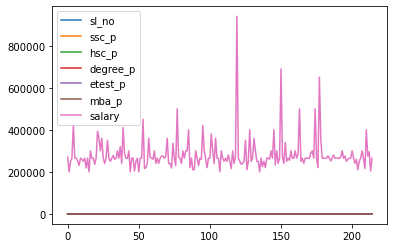

In [30]:
df.plot()

<AxesSubplot:>

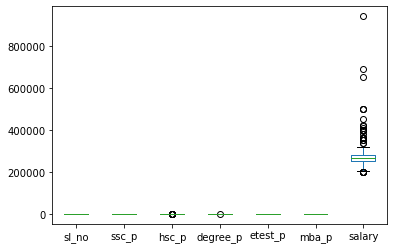

In [31]:
#make a specific kind of plot

df.plot(kind = 'box')

In [32]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Box plot on SCC passing criteria')

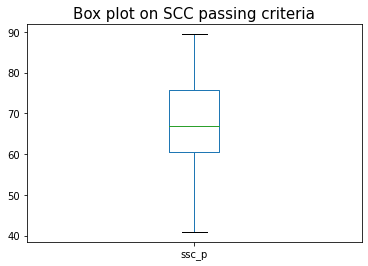

In [33]:
#make a plot on single feature

plt.figure()
df['ssc_p'].plot(kind = 'box')

plt.title('Box plot on SCC passing criteria', fontsize=15)


* Compare how many students are placed after degree. 

<AxesSubplot:xlabel='degree_p', ylabel='status'>

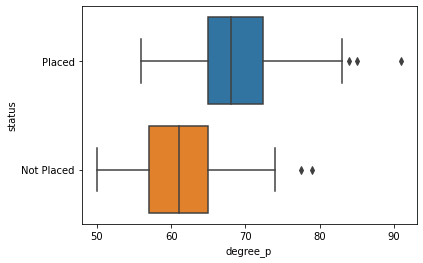

In [34]:
plt.figure()

sns.boxplot(x = 'degree_p', y = 'status', data=df)

<AxesSubplot:xlabel='salary', ylabel='status'>

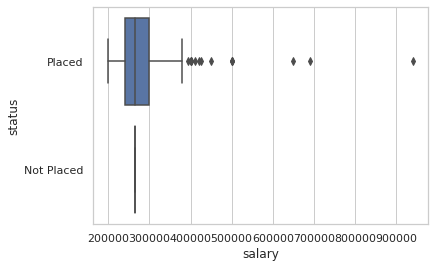

In [35]:
plt.figure()

sns.set_theme(style="whitegrid")
sns.boxplot(x = 'salary', y = 'status', data=df)

* Here, I am explore box plot. like line width, hue.

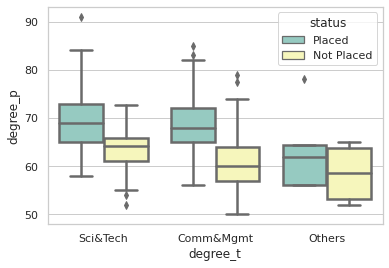

In [36]:
plt.figure()


ax = sns.boxplot(x = 'degree_t', y = 'degree_p', data=df, hue='status', palette='Set3', linewidth=2.5)

* From above graph coluded that maximum students are palced of science stream as well comm & mangement with high salary.

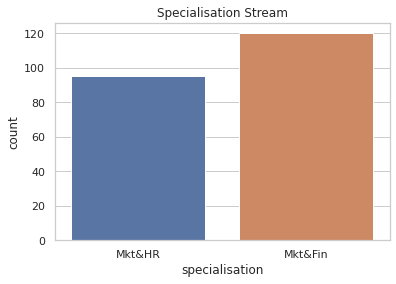

In [37]:
# box order by passing an explicit order:

plt.figure()


ax = sns.countplot(df['specialisation'])
plt.title('Specialisation Stream')
plt.show()

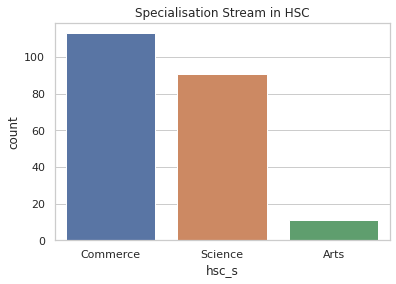

In [38]:
# box order by passing an explicit order:

plt.figure()


ax = sns.countplot(df['hsc_s'])
plt.title('Specialisation Stream in HSC')
plt.show()

Text(0.5, 1.0, 'Specialisation Course')

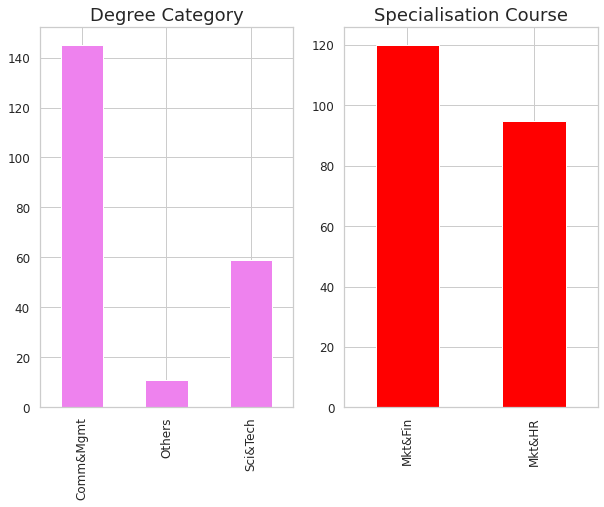

In [39]:
#subplots

fig, axarr = plt.subplots(1,2, figsize=(10,7))

df['degree_t'].value_counts().sort_index().plot.bar(ax=axarr[0], fontsize=12, color='violet')
axarr[0].set_title("Degree Category", fontsize=18)


df['specialisation'].value_counts().sort_index().plot.bar(ax=axarr[1], fontsize=12, color='red')
axarr[1].set_title("Specialisation Course", fontsize=18)



In [40]:
df2=df[df.status=='Placed']
df3=df[df.status=='Not Placed']

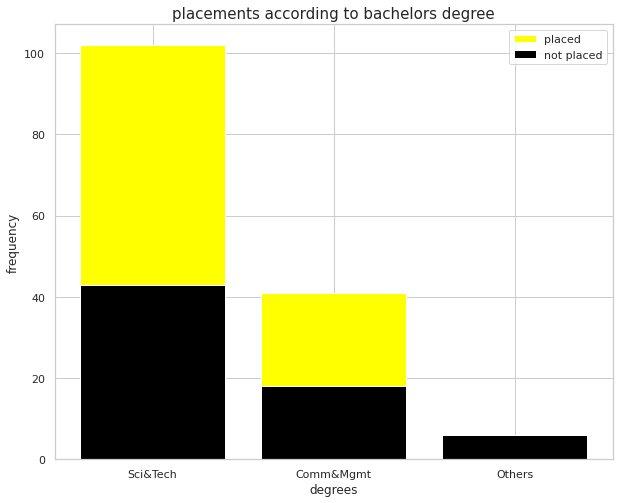

In [41]:
plt.figure(figsize=(10,8))
plt.bar(df2['degree_t'].unique(),height=df2['degree_t'].value_counts(),color='yellow',label='placed')
plt.bar(df3['degree_t'].unique(),height=df3['degree_t'].value_counts(),color='black',label='not placed')


plt.xlabel('degrees')
plt.ylabel('frequency')
plt.title('placements according to bachelors degree',fontsize=15, ha = 'center', fontweight='medium')
plt.legend()

In [42]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,265000.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


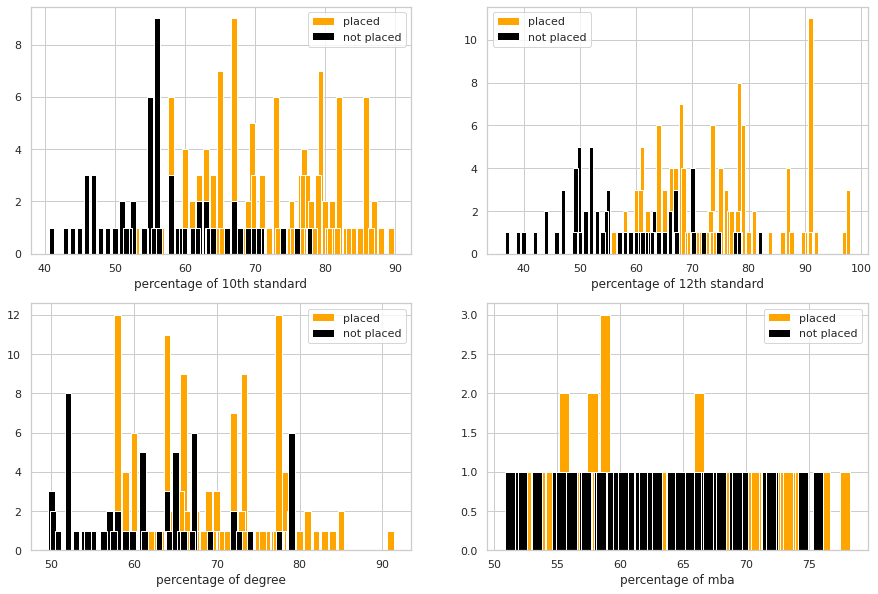

In [43]:
f, ax=plt.subplots(2,2,figsize=(15,10))

ax[0,0].bar(df2['ssc_p'].unique(),height=df2['ssc_p'].value_counts(),color='orange',label='placed')
ax[0,0].bar(df3['ssc_p'].unique(),height=df3['ssc_p'].value_counts(),color='black',label='not placed')
ax[0,0].set_xlabel('percentage of 10th standard')

ax[0,0].legend()
ax[0,1].bar(df2['hsc_p'].unique(),height=df2['hsc_p'].value_counts(),color='orange',label='placed')
ax[0,1].bar(df3['hsc_p'].unique(),height=df3['hsc_p'].value_counts(),color='black',label='not placed')
ax[0,1].set_xlabel('percentage of 12th standard')

ax[0,1].legend()
ax[1,0].bar(df2['degree_p'].unique(),height=df2['degree_p'].value_counts(),color='orange',label='placed')
ax[1,0].bar(df3['degree_p'].unique(),height=df3['degree_p'].value_counts(),color='black',label='not placed')
ax[1,0].set_xlabel('percentage of degree')

ax[1,0].legend()
ax[1,1].bar(df2['mba_p'].unique(),height=df2['mba_p'].value_counts(),color='orange',label='placed')
ax[1,1].bar(df3['mba_p'].unique(),height=df3['mba_p'].value_counts(),color='black',label='not placed')
ax[1,1].set_xlabel('percentage of mba')

plt.legend()

* # <a id='intro'>8. Machine Learning Model</a>

#first split the dataset for training purpose. The aim is first train the model on training dataset then test it on testing data.

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X = df['status']
y = df['status'].drop

In [46]:
#X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [47]:
from sklearn.linear_model import LogisticRegression